In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [9]:
df = pd.read_csv('../data/spotify_data.csv')
df = df.sample(n=5000, random_state = 8)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
84694,22mL6s4MifXlhbIp8du1iW,Barış Manço,Sahibinden İhtiyaçtan,Sahilde,28,201333,False,0.487,0.404,0,-14.163,0,0.0274,0.463000,0.012300,0.5480,0.558,87.451,4,psych-rock
82178,4qf7vg5tXAztGb90vzIGUh,The 20 Belows,Wreckage,Wreckage,27,143369,False,0.282,0.926,1,-2.044,0,0.0536,0.000057,0.273000,0.1910,0.531,178.275,4,power-pop
104027,1hLgXDyabDLzzuAxujQPBU,Lola Indigo;TINI;Belinda,Perreo Tenebroso Vol. 2,La Niña de la Escuela,0,204414,False,0.707,0.876,1,-1.887,1,0.0787,0.173000,0.000009,0.9320,0.853,176.068,4,spanish
23283,3dSufNX8zV2Dz6vmxcQW2w,Alex Cruz;Brascon;Rubenson,Crazy,Crazy,64,232733,False,0.849,0.563,11,-8.471,0,0.0438,0.228000,0.000448,0.0664,0.623,117.009,4,deep-house
87777,2N3xyXrk3mgMB0p8aaKvQx,Kid Abelha,Acústico (Live),Eu Tive Um Sonho - Ao Vivo,41,197240,False,0.648,0.751,2,-7.795,1,0.0276,0.185000,0.000204,0.7660,0.559,113.927,4,r-n-b


In [10]:
df = df.drop(columns=['track_id'])

In [11]:
df.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
84694,Barış Manço,Sahibinden İhtiyaçtan,Sahilde,28,201333,False,0.487,0.404,0,-14.163,0,0.0274,0.463000,0.012300,0.5480,0.558,87.451,4,psych-rock
82178,The 20 Belows,Wreckage,Wreckage,27,143369,False,0.282,0.926,1,-2.044,0,0.0536,0.000057,0.273000,0.1910,0.531,178.275,4,power-pop
104027,Lola Indigo;TINI;Belinda,Perreo Tenebroso Vol. 2,La Niña de la Escuela,0,204414,False,0.707,0.876,1,-1.887,1,0.0787,0.173000,0.000009,0.9320,0.853,176.068,4,spanish
23283,Alex Cruz;Brascon;Rubenson,Crazy,Crazy,64,232733,False,0.849,0.563,11,-8.471,0,0.0438,0.228000,0.000448,0.0664,0.623,117.009,4,deep-house
87777,Kid Abelha,Acústico (Live),Eu Tive Um Sonho - Ao Vivo,41,197240,False,0.648,0.751,2,-7.795,1,0.0276,0.185000,0.000204,0.7660,0.559,113.927,4,r-n-b


Dropped `track_id` as unique identifiers carry no predictive value for linear regression.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 84694 to 6214
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artists           5000 non-null   object 
 1   album_name        5000 non-null   object 
 2   track_name        5000 non-null   object 
 3   popularity        5000 non-null   int64  
 4   duration_ms       5000 non-null   int64  
 5   explicit          5000 non-null   bool   
 6   danceability      5000 non-null   float64
 7   energy            5000 non-null   float64
 8   key               5000 non-null   int64  
 9   loudness          5000 non-null   float64
 10  mode              5000 non-null   int64  
 11  speechiness       5000 non-null   float64
 12  acousticness      5000 non-null   float64
 13  instrumentalness  5000 non-null   float64
 14  liveness          5000 non-null   float64
 15  valence           5000 non-null   float64
 16  tempo             5000 non-null   float64
 

In [13]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,33.618400,2.270896e+05,0.565180,0.646344,5.259600,-8.180118,0.630000,0.084878,0.310759,0.151140,0.217994,0.477416,122.430101,3.904400
std,22.179557,8.753653e+04,0.171932,0.250324,3.549412,5.061785,0.482853,0.107449,0.330688,0.305918,0.196218,0.258205,30.130743,0.441021
min,0.000000,3.110600e+04,0.000000,0.000020,0.000000,-49.307000,0.000000,0.000000,0.000001,0.000000,0.011600,0.000000,0.000000,0.000000
25%,18.000000,1.761162e+05,0.456000,0.484000,2.000000,-9.936000,0.000000,0.035600,0.017375,0.000000,0.098100,0.263000,99.055750,4.000000
50%,35.000000,2.126915e+05,0.578000,0.686000,5.000000,-6.921000,1.000000,0.048600,0.162500,0.000041,0.132000,0.468500,121.992000,4.000000
75%,50.000000,2.601052e+05,0.691000,0.859000,8.000000,-4.963000,1.000000,0.086125,0.593000,0.034275,0.281000,0.684250,140.289000,4.000000
max,97.000000,1.203613e+06,0.973000,1.000000,11.000000,1.342000,1.000000,0.962000,0.996000,0.999000,0.992000,0.987000,222.605000,5.000000


In [14]:
df.isnull().sum()

artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [15]:
df.columns

Index(['artists', 'album_name', 'track_name', 'popularity', 'duration_ms',
       'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [27]:
df = df.drop(columns=["album_name"])

Dropped album_name as it is unlikely that this feature will contribute to predicting popularity, additionally it would be awkward to encode

In [28]:
df.columns

Index(['artists', 'track_name', 'popularity', 'duration_ms', 'explicit',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature', 'track_genre'],
      dtype='object')

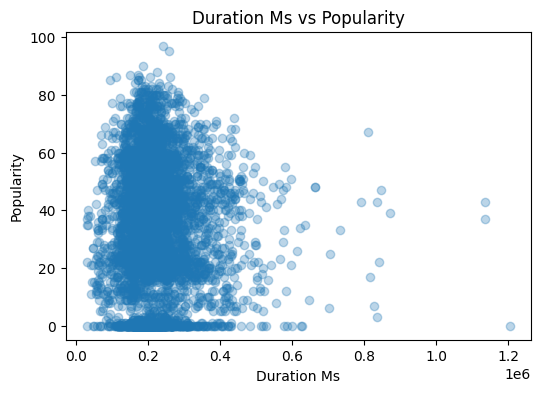

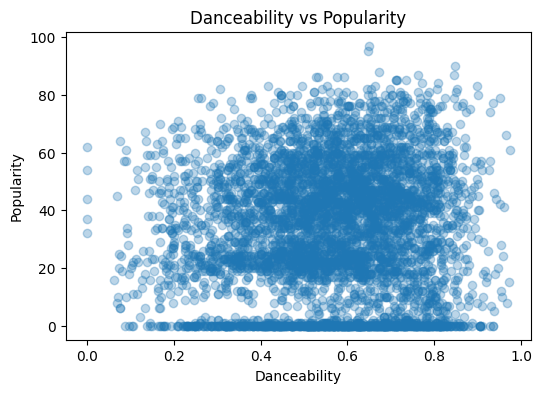

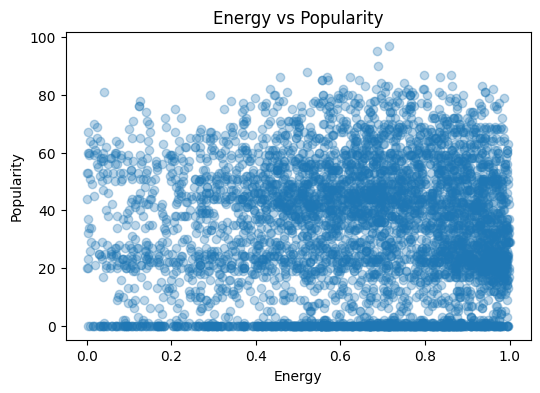

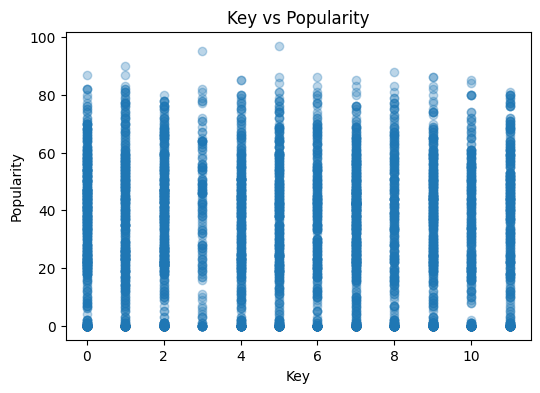

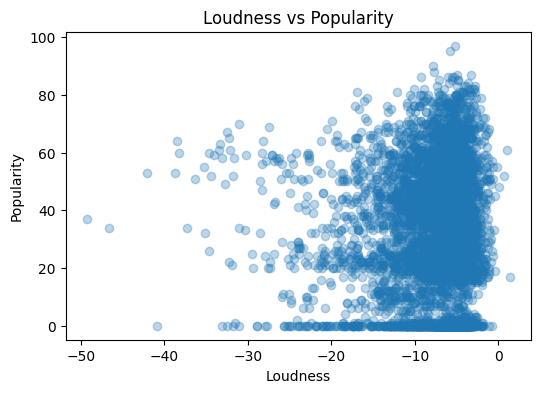

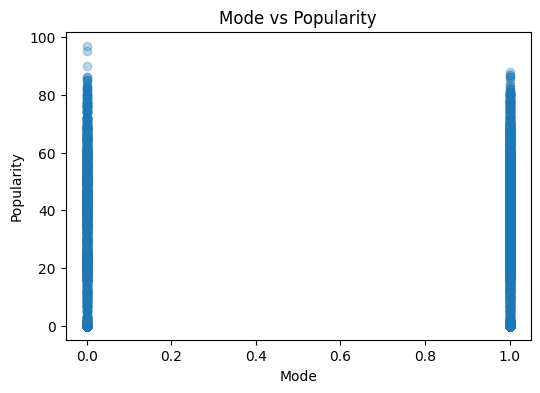

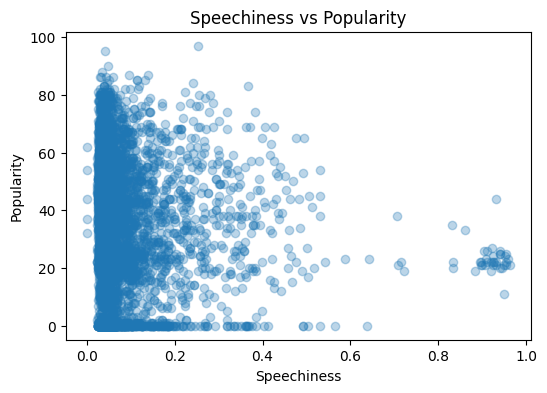

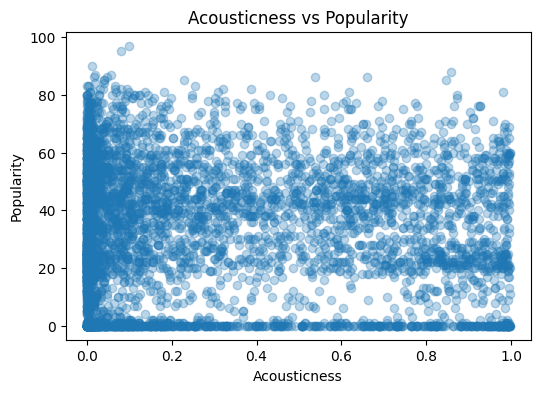

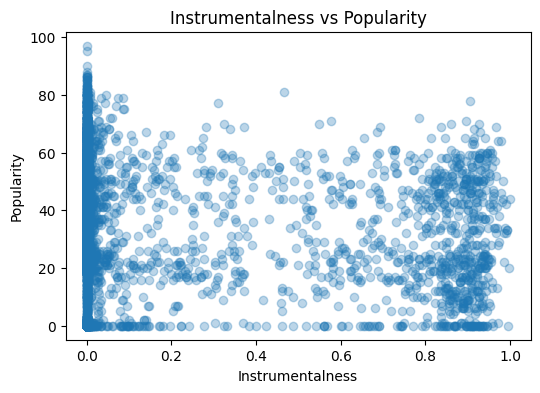

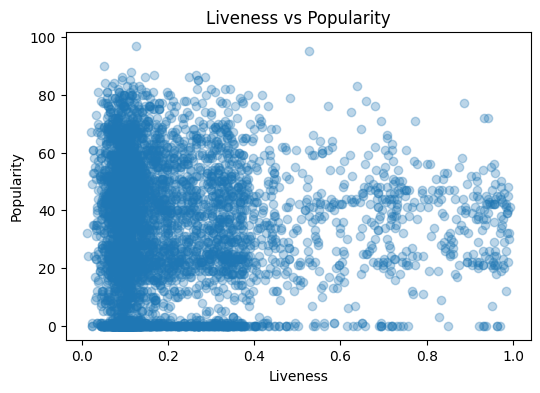

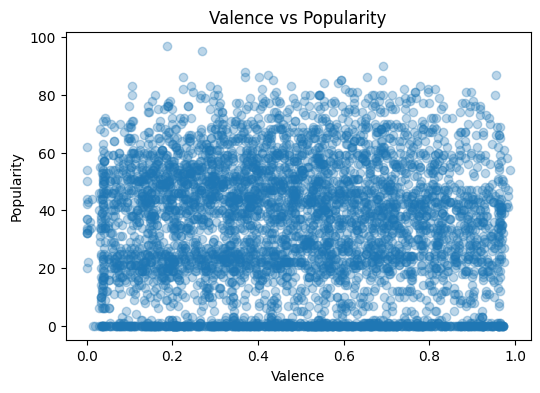

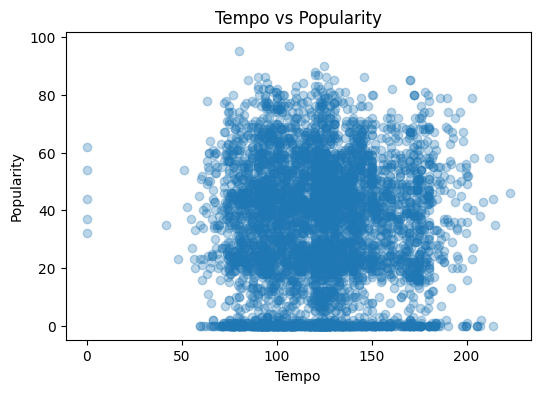

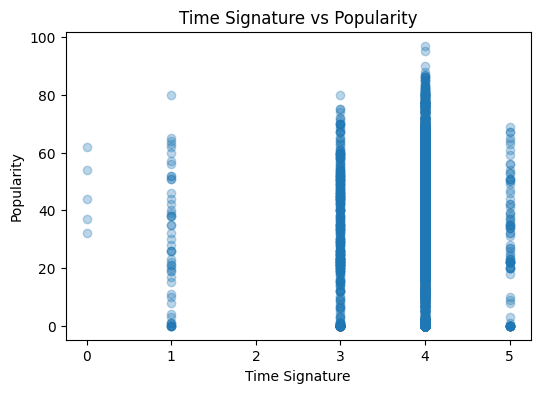

In [29]:
# Select only numerical features (excluding popularity itself)
features = df.select_dtypes(include=['number']).columns.drop('popularity')

for col in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[col], df["popularity"], alpha=0.3)
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel("Popularity")
    plt.title(f"{col.replace('_', ' ').title()} vs Popularity")
    plt.show()